### Neural Operator (Deep-O-Net) Model for Helmolhtz PINN



In [25]:
import torch
import torch.nn as nn
import numpy as np
import copy
import matplotlib.pyplot as plt

In [26]:
# Parameters / Hyperparameters

k_set = [ 10.0, 20.0, 30.0, 35.0, 40.0, 42.0, 44.0, 46.0, 48.0, 50.0 ]
Nf = 2500
adam_epochs = 2500
div0_threshold = 1e-6

In [27]:
# Use GPU if available

torch.set_default_dtype ( torch.float64 )
device = torch.device ( "cuda" if torch.cuda.is_available() else "cpu" )
print ( device )

cuda


In [28]:
# The Model; Deep-O-Net Architecture

class DeepONet_Helmholtz ( nn.Module ):
    def __init__ ( self, n_bank, n_hidden, p_features = 128 ):
        super().__init__()

        self.n_bank = n_bank
        self.n_hidden = n_hidden
        self.p_features = p_features

        self.branch_layers = nn.ModuleList()
        self.trunk_layers = nn.ModuleList()

        self.branch_layers.append ( nn.Linear ( 1, 130 ) )
        for i in range ( n_hidden ):
            self.branch_layers.append ( nn.Linear ( 130, 130 ) )
        self.branch_layers.append ( nn.Linear ( 130, p_features ) )

        self.trunk_layers.append ( nn.Linear ( 2 * n_bank, 130 ) )
        for i in range ( n_hidden ):
            self.trunk_layers.append ( nn.Linear ( 130, 130 ) )
        self.trunk_layers.append ( nn.Linear ( 130, p_features ) )
        
        self.apply ( self.init_weights )

    def init_weights ( self, m ):
        if isinstance ( m, nn.Linear ):
            torch.nn.init.xavier_uniform_ ( m.weight )
            if m.bias is not None:
                m.bias.data.fill_ ( 0.0 )

    def fourier_bank ( self, x ):
        i = torch.arange ( 1, self.n_bank + 1, device = x.device ).to ( x.dtype )
        sin_bank = torch.sin ( x * i )
        cos_bank = torch.cos ( x * i )
        return torch.cat ( [ sin_bank, cos_bank ], dim = -1 )

    def forward ( self, k, x ):
        out_b = k
        for i in range ( self.n_hidden + 1 ):
            out_b = torch.sin ( self.branch_layers[i]( out_b ) )
        out_b = self.branch_layers[-1]( out_b )

        out_t = self.fourier_bank ( x )
        for i in range ( self.n_hidden + 1 ):
            out_t = torch.sin ( self.trunk_layers[i]( out_t ) )
        out_t = self.trunk_layers[-1]( out_t )

        network_out = torch.sum ( out_b * out_t, dim = -1, keepdim = True )

        boundary_line = 1.0 - 2.0 * x
        distance_func = x * ( 1.0 - x )
        
        p_hat = boundary_line + distance_func * network_out
        return p_hat

In [29]:
# Net loss

def operator_loss ( model, k, x, return_pointwise = False ):
    pred = model ( k, x )
    
    dp_dx = torch.autograd.grad (
        outputs = pred,
        inputs = x,
        grad_outputs = torch.ones_like ( pred ),
        create_graph = True,
        retain_graph = True )[0]
    
    d2p_dx2 = torch.autograd.grad (
        outputs = dp_dx,
        inputs = x,
        grad_outputs = torch.ones_like ( dp_dx ),
        create_graph = True,
        retain_graph = True )[0]

    residual = ( d2p_dx2 / k ) + ( k * pred )

    if return_pointwise:
        return torch.abs ( residual )

    return torch.mean ( residual ** 2 )

In [30]:
# Training

k_tensor = torch.tensor ( k_set, device = device, dtype = torch.float64 ).view ( -1, 1 )
x_f_base = torch.linspace ( 0, 1, Nf, device = device ).view ( -1, 1 )

k_grid, x_grid = torch.meshgrid ( k_tensor.flatten(), x_f_base.flatten(), indexing = 'ij' )
k_train = k_grid.reshape ( -1, 1 )
x_train = x_grid.reshape ( -1, 1 )
x_train.requires_grad = True

model = DeepONet_Helmholtz ( n_bank = 65, n_hidden = 7, p_features = 128 ).to ( device )
adam_opt = torch.optim.Adam ( model.parameters(), lr = 0.001, weight_decay = 1e-5 )
loss_history = []

print ( "INFO: Adam Training Started" )    
for epoch in range ( adam_epochs ):
    adam_opt.zero_grad()
    loss = operator_loss ( model, k_train, x_train )
    loss.backward()
    adam_opt.step()
    
    loss_history.append ( loss.item() )
    
    if ( epoch ) % 100 == 0:
        print ( "INFO: Adam Iteration: {}; Loss: {}".format ( len ( loss_history ) - 1, loss.item() ) )

print ( "INFO: Adam Training Done\n" )

opt = torch.optim.LBFGS (
    model.parameters(),
    lr = 1.0,
    max_iter = 10000, 
    line_search_fn = "strong_wolfe" )

def closure():
    opt.zero_grad()
    loss = operator_loss ( model, k_train, x_train )
    loss.backward()
    
    loss_history.append ( loss.item() )
    if len ( loss_history ) % 1000 == 0:
        print ( "INFO: LBFGS Iteration: {}; Loss: {}".format ( len ( loss_history ), loss.item() ) )
    return loss

print ( "INFO: LBFGS Training Started" )
opt.step ( closure )
print ( "INFO: LBFGS Training Done\n" )

INFO: Adam Training Started
INFO: Adam Iteration: 0; Loss: 877.652153481353
INFO: Adam Iteration: 100; Loss: 19.161870390597482
INFO: Adam Iteration: 200; Loss: 10.599767109114044
INFO: Adam Iteration: 300; Loss: 8.524267580479655
INFO: Adam Iteration: 400; Loss: 7.07512946582839
INFO: Adam Iteration: 500; Loss: 4.994037112488861
INFO: Adam Iteration: 600; Loss: 4.749336987786621
INFO: Adam Iteration: 700; Loss: 5.009173452514033
INFO: Adam Iteration: 800; Loss: 3.7458137560036637
INFO: Adam Iteration: 900; Loss: 6.848226819165371
INFO: Adam Iteration: 1000; Loss: 3.9305034634746865
INFO: Adam Iteration: 1100; Loss: 4.169055487933421
INFO: Adam Iteration: 1200; Loss: 3.486939183600194
INFO: Adam Iteration: 1300; Loss: 3.4685841960520234
INFO: Adam Iteration: 1400; Loss: 4.131930265615587
INFO: Adam Iteration: 1500; Loss: 3.469249799275504
INFO: Adam Iteration: 1600; Loss: 3.27553363509689
INFO: Adam Iteration: 1700; Loss: 6.2639072308104335
INFO: Adam Iteration: 1800; Loss: 4.473024538

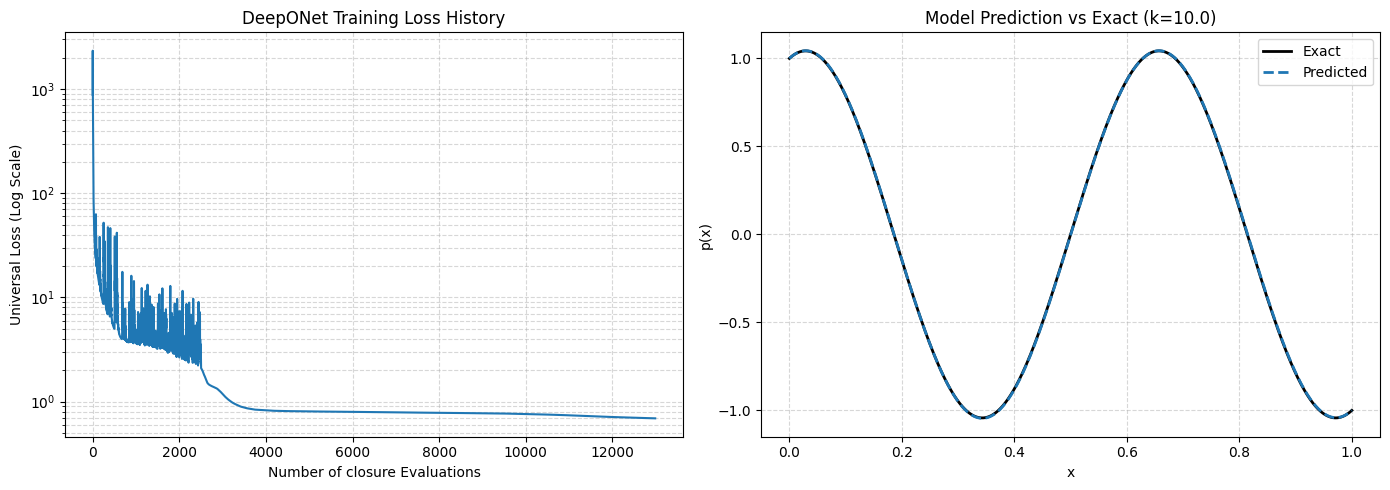

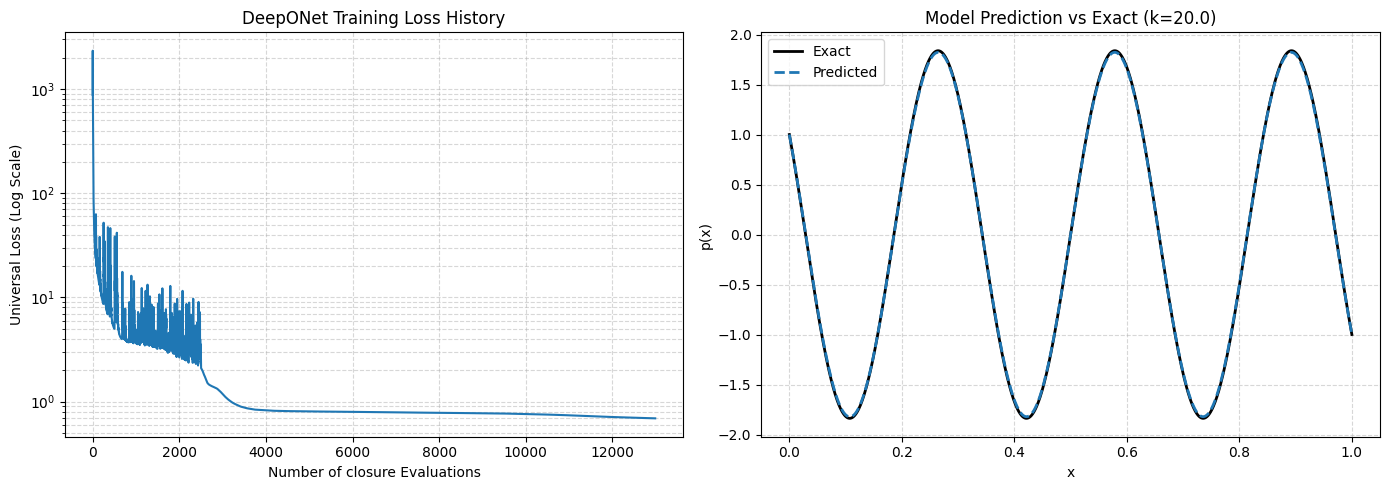

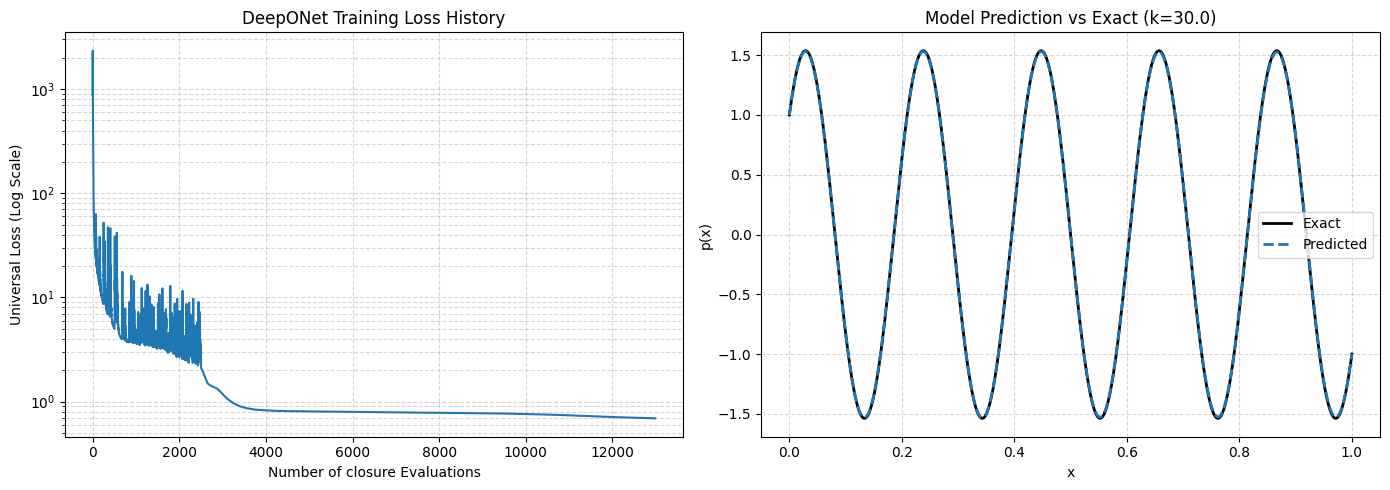

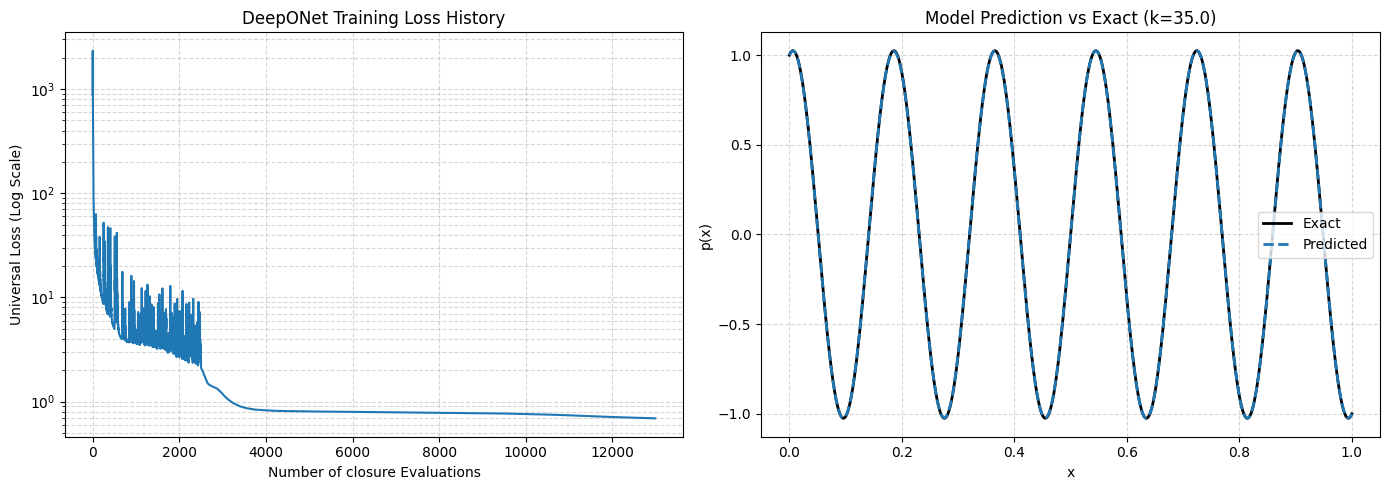

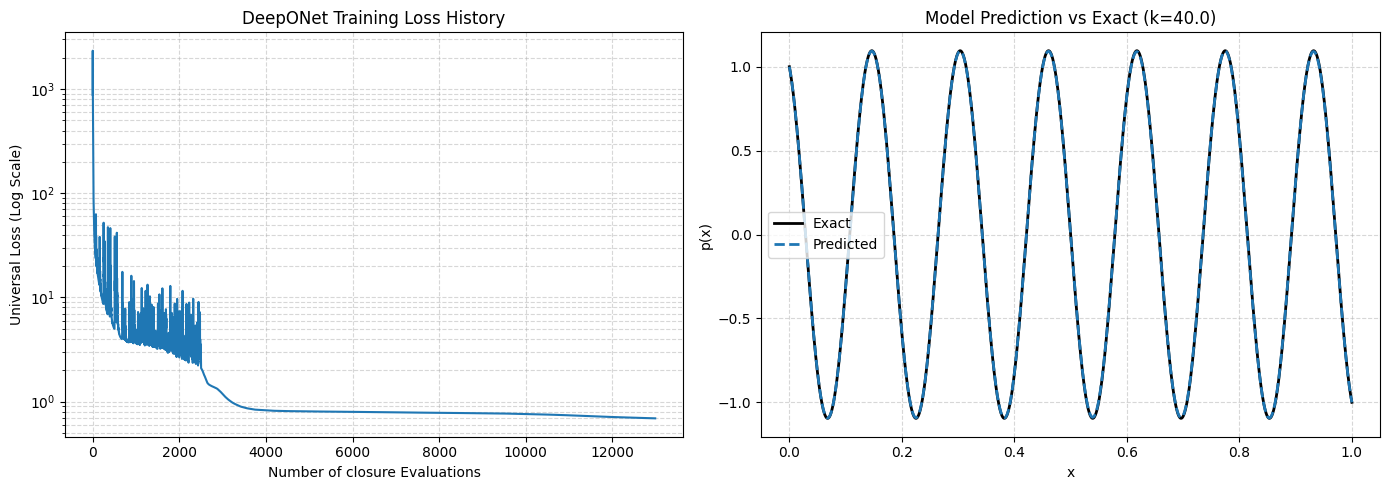

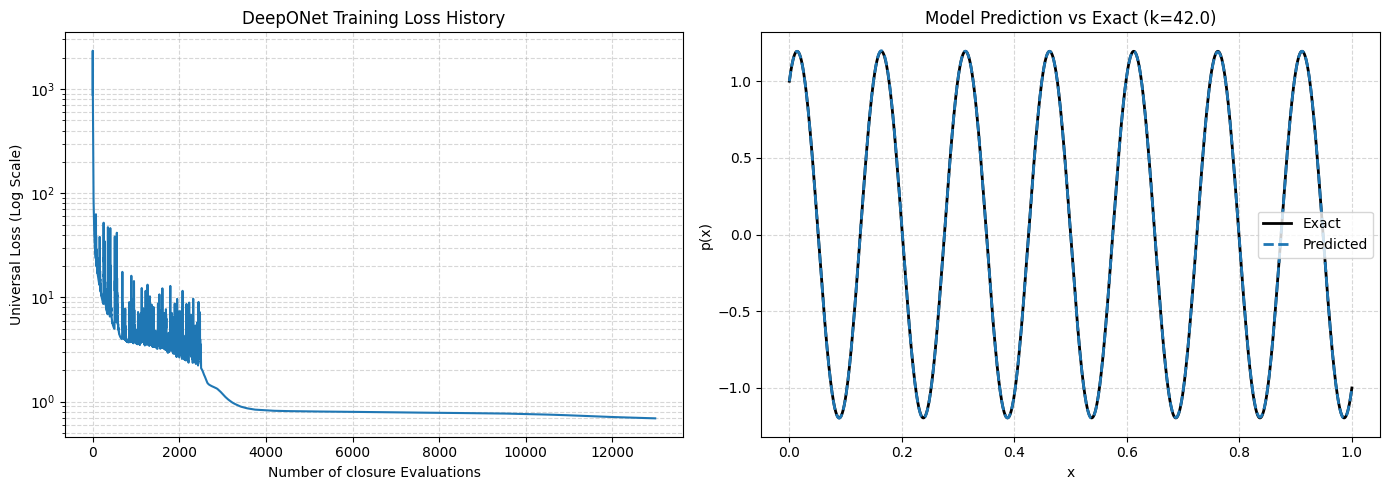

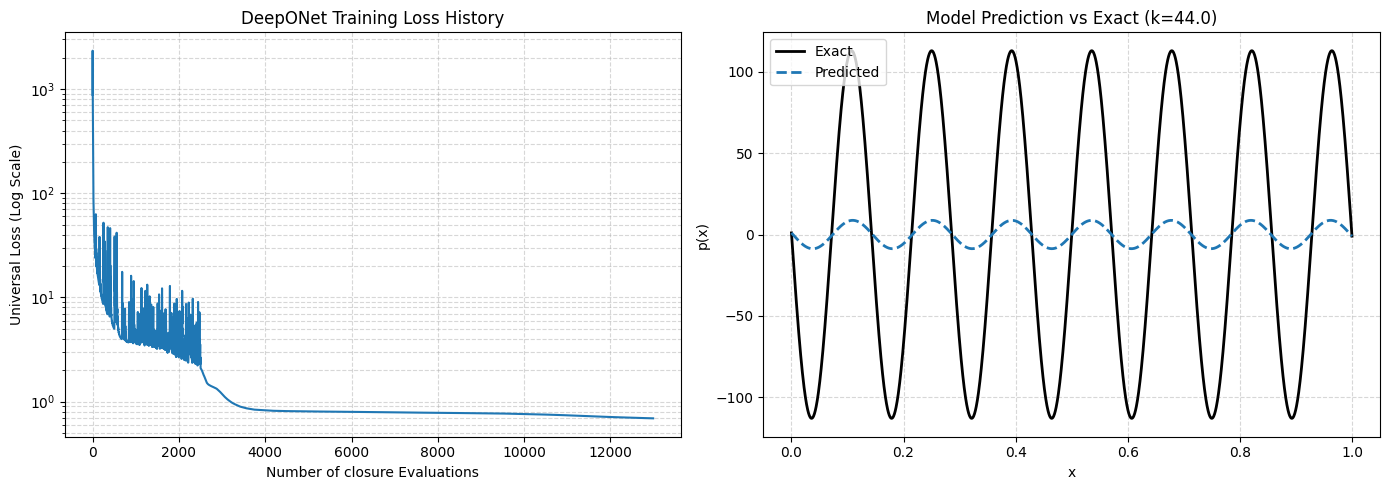

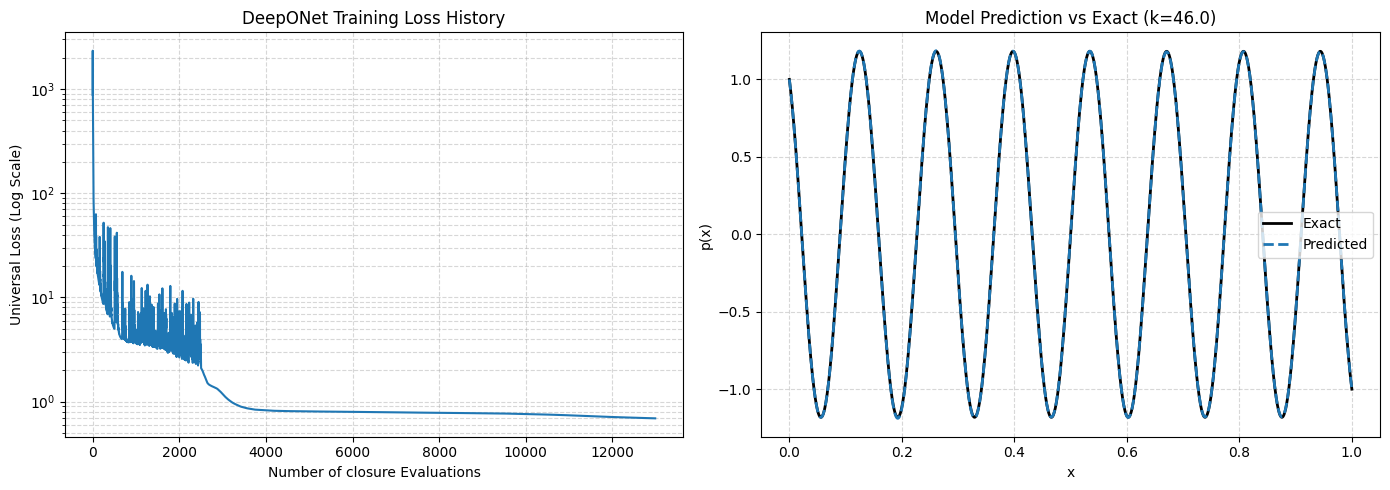

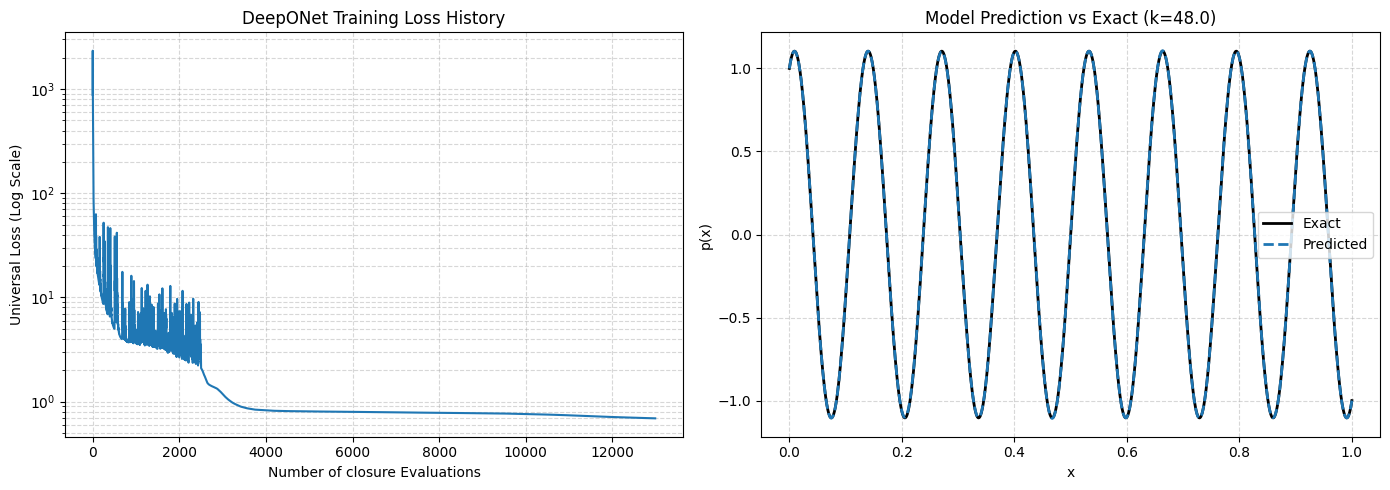

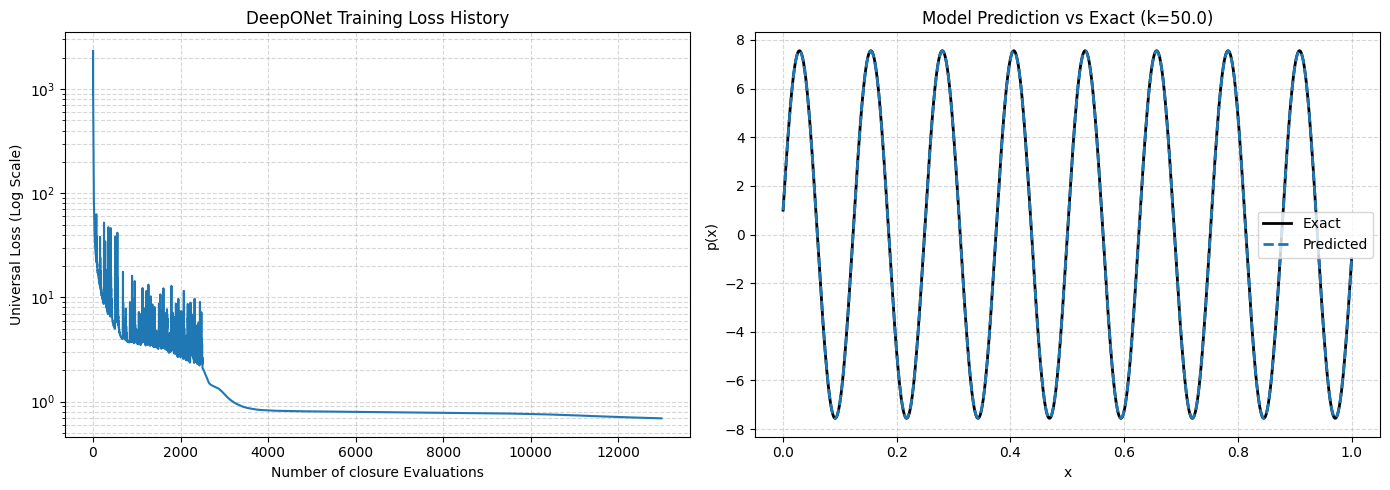

In [31]:
# Plotting solution

def exact_solution ( x, k ):
    if abs ( np.sin( k ) ) < 1e-6:
        return np.zeros_like ( x )
        
    c1 = 1.0
    c2 = - ( 1.0 + np.cos ( k ) ) / np.sin ( k )
    return c1 * np.cos ( k * x ) + c2 * np.sin ( k * x )

for k in k_set:
    with torch.no_grad():
        x_plot = torch.linspace ( 0, 1, 2000, device = device ).view ( -1, 1 )
        
        k_plot = torch.full_like ( x_plot, k )
        
        x_eval = x_plot.cpu().numpy().flatten()
        pred_eval = model ( k_plot, x_plot ).cpu().numpy().flatten()
        exact_eval = exact_solution ( x_eval, k )

    fig, axs = plt.subplots ( 1, 2, figsize = (14, 5))

    axs[0].plot ( loss_history )
    axs[0].set_yscale ( "log" )
    axs[0].set_xlabel ( "Number of closure Evaluations" )
    axs[0].set_ylabel ( "Universal Loss (Log Scale)" )
    axs[0].set_title ( "DeepONet Training Loss History" )
    axs[0].grid ( True, which = "both", linestyle="--", alpha = 0.5 )

    axs[1].plot ( x_eval, exact_eval, 'k-', linewidth = 2, label = "Exact" )
    axs[1].plot ( x_eval, pred_eval, '--', linewidth = 2, label = "Predicted" )
    axs[1].set_xlabel ( "x" )
    axs[1].set_ylabel ( "p(x)" )
    axs[1].set_title ( f"Model Prediction vs Exact (k={k})" )
    axs[1].grid ( True, linestyle = "--", alpha = 0.5 )
    axs[1].legend()

    plt.tight_layout()
    plt.show()